# Part A: Data preprocessing 

0. Imports and configs 


In [1]:
import os
import random
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

IMAGES_DIR = Path("data/images/Images")
ANNOTATIONS_DIR = Path("data/annotations/Annotation")

1. Functions 

In [2]:
def parse_annotation(annotation_path):
    """Parse XML annotation and return bounding box normalized to [0, 1]. 0 is top left and 1 is bottom right"""
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    obj = root.find("object")
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text) / width
    ymin = int(bndbox.find("ymin").text) / height
    xmax = int(bndbox.find("xmax").text) / width
    ymax = int(bndbox.find("ymax").text) / height

    return [xmin, ymin, xmax, ymax]


def load_and_preprocess(image_path, label, bbox):
    """Load image, decodes the jpeg, resize, normalize, and return as tensor"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, {"class_output": label, "bbox_output": bbox}


def build_dataset(paths, labels, bboxes, shuffle=False):
    """Takes in the image paths, labels, and bounding boxes and returns a tf.data.Dataset 
    where the first column is the imagepath  and the second column is the label and the third column is the bounding box"""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels, bboxes)) #creates a dataset from the input tensors
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE) #applies the load_and_preprocess function to each element of the dataset
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) #batches the dataset and prefetches the next batch
    return ds


def plot_breed_distribution(y_train, y_val, y_test, label_to_breed, num_classes):
    """Grouped horizontal bar chart of samples per breed across splits."""
    breed_names = [label_to_breed[i] for i in range(num_classes)]
    train_counts = [np.sum(y_train == i) for i in range(num_classes)]
    val_counts   = [np.sum(y_val == i)   for i in range(num_classes)]
    test_counts  = [np.sum(y_test == i)  for i in range(num_classes)]

    y_pos = np.arange(num_classes)
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.barh(y_pos - bar_h, train_counts, bar_h, label=f"Train ({len(y_train)})", color="#4c72b0")
    ax.barh(y_pos,         val_counts,   bar_h, label=f"Val ({len(y_val)})",     color="#55a868")
    ax.barh(y_pos + bar_h, test_counts,  bar_h, label=f"Test ({len(y_test)})",   color="#c44e52")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(breed_names, fontsize=9)
    ax.set_xlabel("Number of Images")
    ax.set_title("Samples per Breed by Split")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


2. Downlaoding the data, donwloads only once

#set up kaggle credential for download


In [3]:


DATA_DIR = Path("data")

if not DATA_DIR.exists():
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "jessicali9530/stanford-dogs-dataset", "--unzip", "-p", "./data"],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print("Dataset downloaded and extracted to ./data")
    else:
        stderr = (result.stderr or "").strip()
        missing_auth = (
            "KeyError: 'username'" in stderr
            or "Could not find kaggle.json" in stderr
            or "credentials" in stderr.lower()
        )

        if missing_auth:
            print("Kaggle credentials were not found on this machine.")
            print("Each user should configure their own Kaggle account locally:")
            print("  1) Create ~/.kaggle/kaggle.json with your own username and API key")
            print("  2) Run: chmod 600 ~/.kaggle/kaggle.json")
            print("  3) Re-run this cell")
        else:
            print(f"Download failed:\n{stderr}")
else:
    print("Dataset already exists at ./data")

Dataset already exists at ./data


2. Breed selection and label mapping

In [4]:
SELECTED_BREEDS = [
    "n02085620-Chihuahua",
    "n02086240-Shih-Tzu",
    "n02087394-Rhodesian_ridgeback",
    "n02088364-beagle",
    "n02089973-English_foxhound",
    "n02091032-Italian_greyhound",
    "n02092339-Weimaraner",
    "n02093256-Staffordshire_bullterrier",
    "n02094433-Yorkshire_terrier",
    "n02096585-Boston_bull",
    "n02097047-miniature_schnauzer",
    "n02099601-golden_retriever",
    "n02099712-Labrador_retriever",
    "n02100877-Irish_setter",
    "n02102318-cocker_spaniel",
    "n02105855-Shetland_sheepdog",
    "n02106166-Border_collie",
    "n02106382-Bouvier_des_Flandres",
    "n02106550-Rottweiler",
    "n02106662-German_shepherd",
    "n02107142-Doberman",
    "n02107683-Bernese_mountain_dog",
    "n02108089-boxer",
    "n02108915-French_bulldog",
    "n02109047-Great_Dane",
    "n02109525-Saint_Bernard",
    "n02110185-Siberian_husky",
    "n02110958-pug",
    "n02111889-Samoyed",
    "n02112018-Pomeranian",
]

breed_to_label = {breed: i for i, breed in enumerate(SELECTED_BREEDS)} #labels are numerical class
label_to_breed = {i: breed.split("-", 1)[1] for i, breed in enumerate(SELECTED_BREEDS)}
NUM_CLASSES = len(SELECTED_BREEDS)

print(f"Selected {NUM_CLASSES} breeds:")
for i, breed in label_to_breed.items():
    print(f"  {i:2d}: {breed}")

Selected 30 breeds:
   0: Chihuahua
   1: Shih-Tzu
   2: Rhodesian_ridgeback
   3: beagle
   4: English_foxhound
   5: Italian_greyhound
   6: Weimaraner
   7: Staffordshire_bullterrier
   8: Yorkshire_terrier
   9: Boston_bull
  10: miniature_schnauzer
  11: golden_retriever
  12: Labrador_retriever
  13: Irish_setter
  14: cocker_spaniel
  15: Shetland_sheepdog
  16: Border_collie
  17: Bouvier_des_Flandres
  18: Rottweiler
  19: German_shepherd
  20: Doberman
  21: Bernese_mountain_dog
  22: boxer
  23: French_bulldog
  24: Great_Dane
  25: Saint_Bernard
  26: Siberian_husky
  27: pug
  28: Samoyed
  29: Pomeranian


3. GOes through each image, the image is added to img_paths list, the bb are extracted and normalized and added into the bboxes list, and the label(which is the dog bread) is added to the labels list. 

In [5]:
image_paths = []  #array of image paths
labels = [] #array of labels which is the dog bread
bboxes = [] #array of bounding boxes, each element is a list of 4 numbers [xmin, ymin, xmax, ymax]
skipped = 0 #number of images skipped



for breed_folder in SELECTED_BREEDS:
    label = breed_to_label[breed_folder]
    img_dir = IMAGES_DIR / breed_folder
    ann_dir = ANNOTATIONS_DIR / breed_folder

    for img_file in sorted(img_dir.glob("*.jpg")):
        ann_file = ann_dir / img_file.stem
        if not ann_file.exists():
            skipped += 1
            continue
        try:
            bbox = parse_annotation(ann_file) # function to parse the annotation and return the normalized bounding box for the gicen image
            image_paths.append(str(img_file))
            labels.append(label)
            bboxes.append(bbox)
        except Exception:
            skipped += 1

image_paths = np.array(image_paths)
labels = np.array(labels)
bboxes = np.array(bboxes, dtype=np.float32)

print(f"Total samples: {len(image_paths)} (skipped {skipped})")
print(f"Labels shape: {labels.shape}, Bboxes shape: {bboxes.shape}")
print(f"\nSamples per breed:")
counts = Counter(labels)
for lbl in sorted(counts):
    print(f"  {label_to_breed[lbl]:30s}: {counts[lbl]}")

Total samples: 5116 (skipped 0)
Labels shape: (5116,), Bboxes shape: (5116, 4)

Samples per breed:
  Chihuahua                     : 152
  Shih-Tzu                      : 214
  Rhodesian_ridgeback           : 172
  beagle                        : 195
  English_foxhound              : 157
  Italian_greyhound             : 182
  Weimaraner                    : 160
  Staffordshire_bullterrier     : 155
  Yorkshire_terrier             : 164
  Boston_bull                   : 182
  miniature_schnauzer           : 154
  golden_retriever              : 150
  Labrador_retriever            : 171
  Irish_setter                  : 155
  cocker_spaniel                : 159
  Shetland_sheepdog             : 157
  Border_collie                 : 150
  Bouvier_des_Flandres          : 150
  Rottweiler                    : 152
  German_shepherd               : 152
  Doberman                      : 150
  Bernese_mountain_dog          : 218
  boxer                         : 151
  French_bulldog           

4. Stratified split: 70% train, 15% validation, 15% test
stratify=labels ensures each breed has the same proportion in every split

In [6]:
X_train, X_temp, y_train, y_temp, bbox_train, bbox_temp = train_test_split( #splits into 70% train, and 30% temp
    image_paths, labels, bboxes,
    test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test, bbox_val, bbox_test = train_test_split( #the 30 temp is split into 15% val and 15% test
    X_temp, y_temp, bbox_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

print(f"\nBreed distribution check (first 5 breeds):")
for lbl in range(5):
    name = label_to_breed[lbl]
    tr = np.sum(y_train == lbl)
    va = np.sum(y_val == lbl)
    te = np.sum(y_test == lbl)
    print(f"  {name:25s} -> train={tr}, val={va}, test={te}")

Train:      3581 samples
Validation: 767 samples
Test:       768 samples

Breed distribution check (first 5 breeds):
  Chihuahua                 -> train=106, val=23, test=23
  Shih-Tzu                  -> train=150, val=32, test=32
  Rhodesian_ridgeback       -> train=120, val=26, test=26
  beagle                    -> train=137, val=29, test=29
  English_foxhound          -> train=110, val=24, test=23


5. Breed distribution across each split

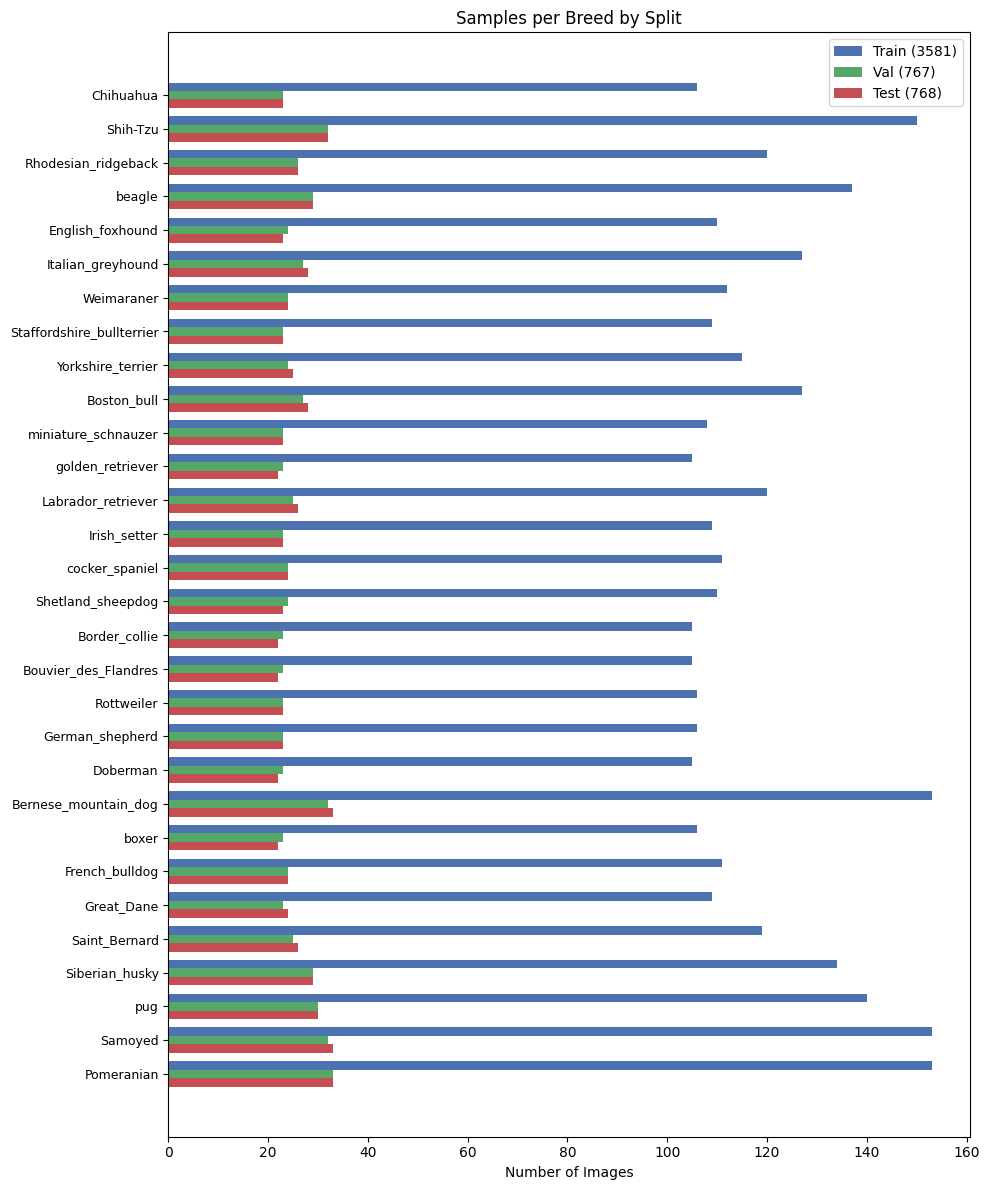

In [7]:
plot_breed_distribution(y_train, y_val, y_test, label_to_breed, NUM_CLASSES)

6. Sanity Check: checking one batch of the trainig to make sure everything is build correctly. 

In [8]:
train_ds = build_dataset(X_train, y_train, bbox_train, shuffle=True) #loads the data into a dataset for training
val_ds = build_dataset(X_val, y_val, bbox_val) #loads the data into a dataset for validation
test_ds = build_dataset(X_test, y_test, bbox_test) #loads the data into a dataset for testing

for images, targets in train_ds.take(1):
    print(f"Image batch shape:  {images.shape}")
    print(f"Labels batch shape: {targets['class_output'].shape}")
    print(f"Bbox batch shape:   {targets['bbox_output'].shape}")
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Image batch shape:  (32, 224, 224, 3)
Labels batch shape: (32,)
Bbox batch shape:   (32, 4)
Pixel range: [0.00, 1.00]


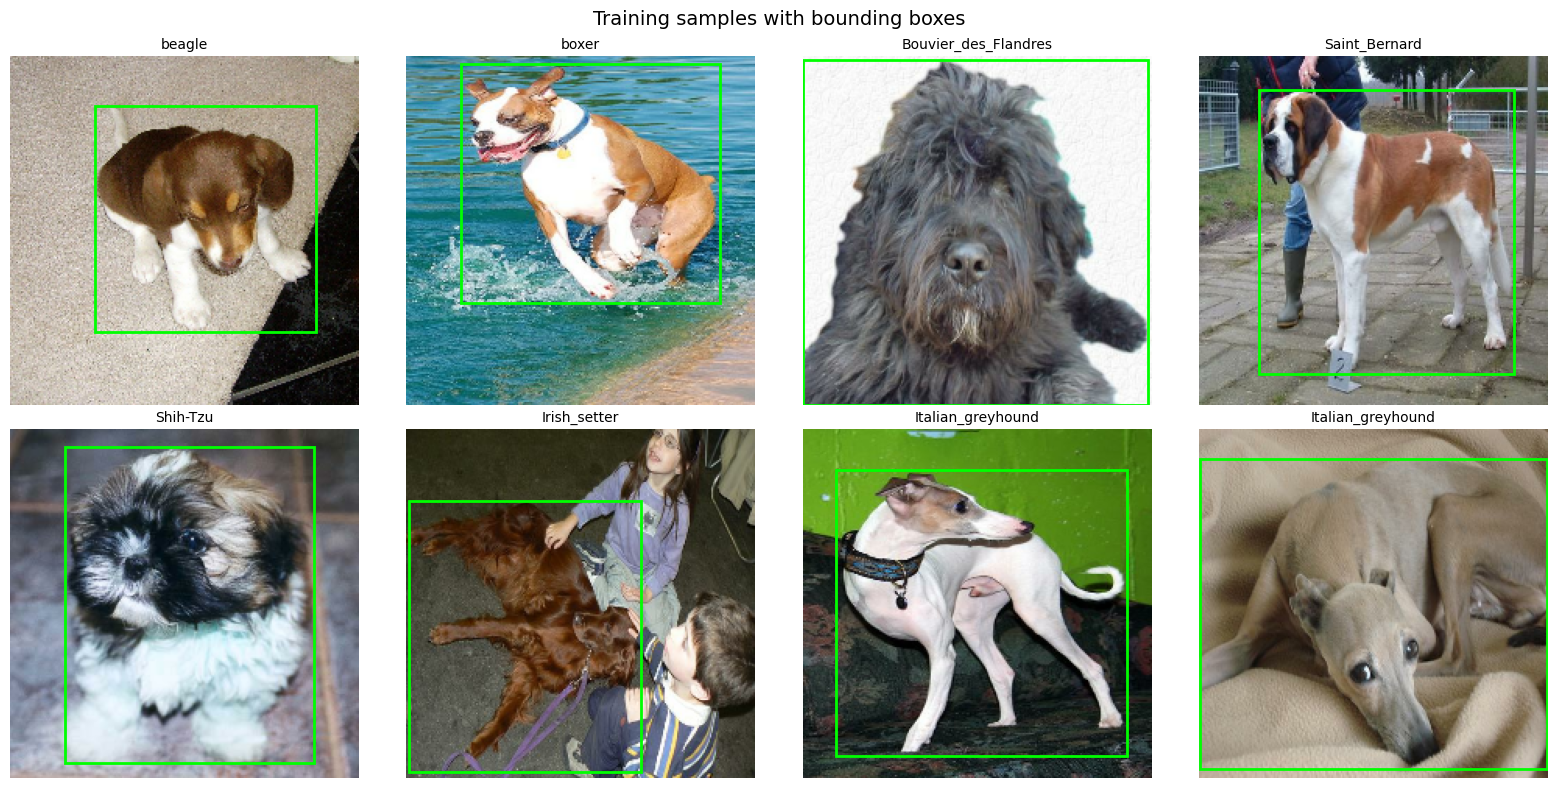

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for images, targets in train_ds.take(1):
    for i in range(8):
        img = images[i].numpy()
        label = targets["class_output"][i].numpy()
        bbox = targets["bbox_output"][i].numpy()

        xmin, ymin, xmax, ymax = bbox
        h, w = IMG_SIZE, IMG_SIZE

        axes[i].imshow(img)
        rect = plt.Rectangle(
            (xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        axes[i].add_patch(rect)
        axes[i].set_title(label_to_breed[label], fontsize=10)
        axes[i].axis("off")

plt.suptitle("Training samples with bounding boxes", fontsize=14)
plt.tight_layout()
plt.show()

# Part B: Model Develpment

In [10]:


# Strip bounding boxes — keep only class labels for this classifier
cls_train_ds = train_ds.map(lambda img, targets: (img, targets["class_output"]))
cls_val_ds   = val_ds.map(lambda img, targets: (img, targets["class_output"]))
cls_test_ds  = test_ds.map(lambda img, targets: (img, targets["class_output"]))

simple_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

simple_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch / 20))

simple_history = simple_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20,
    callbacks=[lr_schedule]
)

Epoch 1/20


/Users/anjalikale/Desktop/Dog_breed_classification/venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 0.0383 - loss: 3.4001 - val_accuracy: 0.0743 - val_loss: 3.3853 - learning_rate: 1.0000e-04
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step - accuracy: 0.0891 - loss: 3.3204 - val_accuracy: 0.0821 - val_loss: 3.2648 - learning_rate: 1.1220e-04
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 248ms/step - accuracy: 0.1148 - loss: 3.1638 - val_accuracy: 0.1160 - val_loss: 3.1130 - learning_rate: 1.2589e-04
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 255ms/step - accuracy: 0.1466 - loss: 3.0392 - val_accuracy: 0.1134 - val_loss: 3.0608 - learning_rate: 1.4125e-04
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 29s 254ms/step - accuracy: 0.1885 - loss: 2.9100 - val_accuracy: 0.1382 - val_loss: 3.0198 - learning_rate: 1.5849e-04
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 250ms/step - accuracy: 0.2268 - loss: 2.7480 - val_accuracy: 0.1486 - val_loss: 2.9899 - learning_rate: 1.7783e-04
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 251ms/step - 

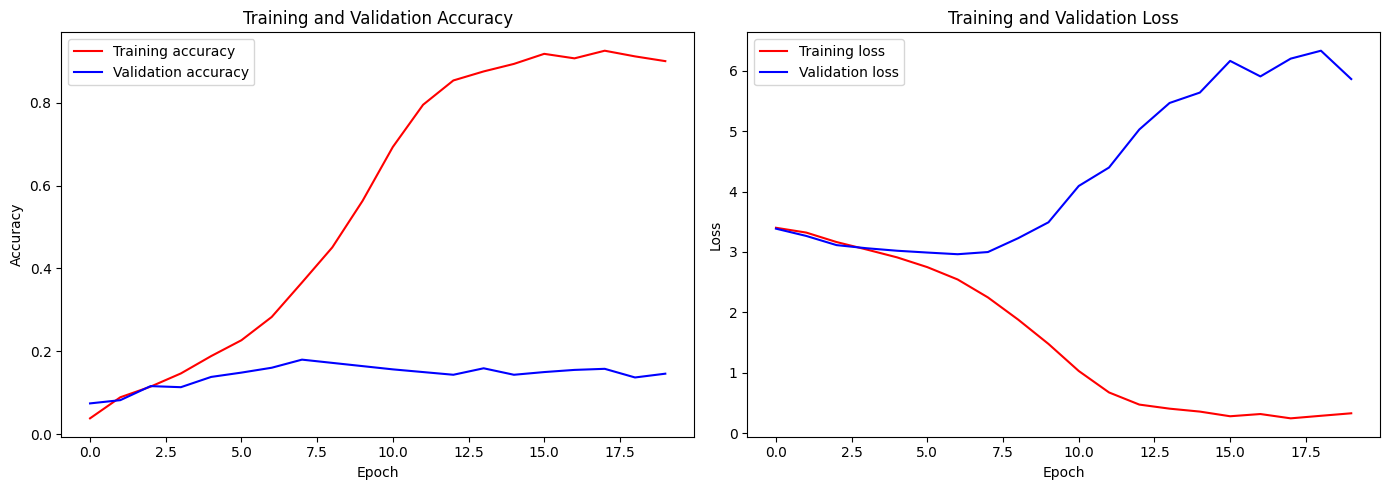

In [11]:
train_acc = simple_history.history['accuracy']
val_acc   = simple_history.history['val_accuracy']
train_loss = simple_history.history['loss']
val_loss   = simple_history.history['val_loss']

epochs = range(len(train_acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, 'r', label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', label='Validation accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, train_loss, 'r', label='Training loss')
ax2.plot(epochs, val_loss, 'b', label='Validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# SECTION 3: MODEL DEVELOPMENT - Anjali Kale
# ============================================
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 30

def build_cnn(num_classes=NUM_CLASSES, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,791,326 (98.39 MB)

 Trainable params: 25,791,326 (98.39 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile and train the CNN
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20
)

print("✅ CNN Training Complete!")

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 60s 532ms/step - accuracy: 0.0394 - loss: 3.4529 - val_accuracy: 0.0482 - val_loss: 3.3986
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 540ms/step - accuracy: 0.0572 - loss: 3.3817 - val_accuracy: 0.0860 - val_loss: 3.3189
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 63s 560ms/step - accuracy: 0.0882 - loss: 3.2531 - val_accuracy: 0.0965 - val_loss: 3.2056
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 74s 658ms/step - accuracy: 0.1452 - loss: 3.0301 - val_accuracy: 0.1160 - val_loss: 3.1434
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 78s 692ms/step - accuracy: 0.2583 - loss: 2.6262 - val_accuracy: 0.1343 - val_loss: 3.2142
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 76s 673ms/step - accuracy: 0.4317 - loss: 1.9723 - val_accuracy: 0.1473 - val_loss: 3.4057
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 79s 701ms/step - accuracy: 0.6090 - loss: 1.3290 - val_accuracy: 0.1160 - val_loss: 4.0542
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 84s 750ms/step - accuracy: 0.7238 - loss: 0

In [14]:
# ============================================
# ResNet50 Transfer Learning - Anjali Kale
# ============================================

base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = tf.keras.Model(inputs, outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,119,966 (92.01 MB)

 Trainable params: 532,254 (2.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
resnet_history = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20
)

print("✅ ResNet Training Complete!")

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 113s 990ms/step - accuracy: 0.0338 - loss: 3.6378 - val_accuracy: 0.0730 - val_loss: 3.3891
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.0410 - loss: 3.4364 - val_accuracy: 0.0522 - val_loss: 3.3797
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.0469 - loss: 3.3962 - val_accuracy: 0.0626 - val_loss: 3.3742
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.0550 - loss: 3.3787 - val_accuracy: 0.0782 - val_loss: 3.3698
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.0578 - loss: 3.3772 - val_accuracy: 0.0808 - val_loss: 3.3666
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.0595 - loss: 3.3663 - val_accuracy: 0.0769 - val_loss: 3.3617
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.0684 - loss: 3.3602 - val_accuracy: 0.0717 - val_loss: 3.3574
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.0600 - loss: 3.3572 - val_a

In [16]:
# ============================================
# ResNet - Improved Version (Fine-tuning)
# ============================================

# Unfreeze the last 30 layers of ResNet
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with higher learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Retrain
resnet_history = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20
)

print("✅ ResNet Fine-tuned Training Complete!")

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.0399 - loss: 3.4340 - val_accuracy: 0.0417 - val_loss: 3.3991
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.0391 - loss: 3.3987 - val_accuracy: 0.0417 - val_loss: 3.3978
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.0397 - loss: 3.3975 - val_accuracy: 0.0417 - val_loss: 3.3969
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.0397 - loss: 3.3965 - val_accuracy: 0.0417 - val_loss: 3.3961
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.0408 - loss: 3.3958 - val_accuracy: 0.0417 - val_loss: 3.3955
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.0397 - loss: 3.3952 - val_accuracy: 0.0417 - val_loss: 3.3950
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.0413 - loss: 3.3947 - val_accuracy: 0.0417 - val_loss: 3.3946
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1033s 9s/step - accuracy: 0.0419 - loss: 3.3944 - val_acc